In [ ]:
# Step 1: Initialize Google Drive Environment
from google.colab import drive
import os

# Mount Google Drive to the local runtime to access persistent storage
drive.mount('/content/drive')

# Define the absolute path to the main project directory
base_path = '/content/drive/MyDrive/BDA_CEP_TimeGAN'

# Validate that the project directory exists before proceeding
if os.path.exists(base_path):
    print(f"Success! Project folder found at: {base_path}")

    # Define paths for sub-directories (data, models, outputs) for easier reference
    data_dir = os.path.join(base_path, 'data')
    model_dir = os.path.join(base_path, 'models')
    output_dir = os.path.join(base_path, 'outputs')

    print("Directories initialized successfully.")
else:
    # Raise an error message if the directory structure is missing
    print("Error: Directory not found. Please ensure the folder 'BDA_CEP_TimeGAN' exists in your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! Project folder found at: /content/drive/MyDrive/BDA_CEP_TimeGAN
Directories set up successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, losses

# --- TimeGAN Component Definitions ---

def make_embedder(seq_len, n_features, hidden_dim):
    """
    Embedder Network: Encodes high-dimensional temporal data into a
    lower-dimensional latent space representation.
    """
    model = tf.keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.GRU(hidden_dim, return_sequences=True),
        layers.GRU(hidden_dim, return_sequences=True),
        # Projects features to latent space using Sigmoid activation
        layers.Dense(hidden_dim, activation='sigmoid')
    ], name="Embedder")
    return model

def make_recovery(seq_len, hidden_dim, n_features):
    """
    Recovery Network: Decodes latent space representations back into
    the original feature space (Reconstruction).
    """
    model = tf.keras.Sequential([
        layers.Input(shape=(seq_len, hidden_dim)),
        layers.GRU(hidden_dim, return_sequences=True),
        layers.GRU(hidden_dim, return_sequences=True),
        # Reconstructs original data. Sigmoid is used assuming data is scaled [0, 1]
        layers.Dense(n_features, activation='sigmoid')
    ], name="Recovery")
    return model

def make_generator(seq_len, hidden_dim):
    """
    Generator Network: Generates synthetic latent embeddings from
    random noise sequences.
    """
    model = tf.keras.Sequential([
        layers.Input(shape=(seq_len, hidden_dim)), # Input: Random Noise
        layers.GRU(hidden_dim, return_sequences=True),
        layers.GRU(hidden_dim, return_sequences=True),
        # Outputs generated latent features
        layers.Dense(hidden_dim, activation='sigmoid')
    ], name="Generator")
    return model

def make_discriminator(seq_len, hidden_dim):
    """
    Discriminator Network: Classifies latent sequences as either
    real (from Embedder) or synthetic (from Generator).
    """
    model = tf.keras.Sequential([
        layers.Input(shape=(seq_len, hidden_dim)),
        layers.GRU(hidden_dim, return_sequences=True),
        layers.GRU(hidden_dim, return_sequences=True),
        # Output score (Logits) for binary classification (Real vs. Fake)
        layers.Dense(1, activation=None)
    ], name="Discriminator")
    return model

# --- Optimization Configuration ---

# Initialize Adam optimizers for each network component with a fixed learning rate.
# Adam is the standard optimizer for handling non-stationary objectives in GANs.
embedder_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
recovery_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

print("✅ TimeGAN Architecture Defined Successfully!")
print("Next Step: Initialize the models and begin the training loop.")

✅ TimeGAN Architecture Defined Successfully!
Ab hum next step mein isko initialize aur train karenge.


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

# Step 1: Mount Google Drive
# Force remount ensures the drive is freshly connected if connection was lost
drive.mount('/content/drive', force_remount=True)

# Step 2: Define File Configuration
# Absolute path to the Bitcoin dataset within the project directory
file_path = '/content/drive/MyDrive/BDA_CEP_TimeGAN/bitcoin.csv'

print(f"Verifying file existence at: {file_path}")

if os.path.exists(file_path):
    # Step 3: Data Loading and Preprocessing Pipeline
    print("File found. Loading dataset into memory...")
    df = pd.read_csv(file_path)

    # Convert 'Timestamp' from Unix epoch format to datetime objects
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
    df = df.set_index('Timestamp')

    # Resample data to Daily frequency ('D') to reduce noise
    # .ffill() and .bfill() handle any missing intervals by propagating adjacent values
    df_daily = df.resample('D').mean().ffill().bfill()

    # Feature Selection: Dynamically find the Volume column and define OHLCV features
    vol_col = [c for c in df_daily.columns if "Volume" in c][0]
    features = ['Open', 'High', 'Low', 'Close', vol_col]
    data_values = df_daily[features].values

    # Feature Scaling: Normalize data to range [0, 1]
    # This is crucial for Neural Networks (especially GANs using Sigmoid activation)
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data_values)

    # Step 4: Sequence Generation (Sliding Window Approach)
    seq_len = 24  # Define window size (e.g., 24 days per sequence)
    data_seq = []

    # Iterate through the data to create overlapping sequences
    for i in range(len(data_scaled) - seq_len):
        data_seq.append(data_scaled[i : i + seq_len])

    # Convert list to NumPy array and shuffle for unbiased training
    data_seq = np.array(data_seq)
    np.random.shuffle(data_seq)

    print("\n------------------------------------------")
    print("✅ Data Pipeline Executed Successfully.")
    print(f"Data Shape: {data_seq.shape} (Samples, Time Steps, Features)")
    print("Ready for Training. Proceed to the Model Training step.")
    print("------------------------------------------")

else:
    print(f"❌ Error: File not found at path: {file_path}")
    print("Action Required: Please verify the folder name 'BDA_CEP_TimeGAN' in your Google Drive.")

Mounted at /content/drive
Checking file at: /content/drive/MyDrive/BDA_CEP_TimeGAN/bitcoin.csv
Reading file... (Wait karo)

------------------------------------------
✅ MASLA HAL HO GAYA!
data_seq wapis aa gaya hai. Shape: (5062, 24, 5)
Ab tum Training wala code (Step 4) dobara run kar sakte ho.
------------------------------------------


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, losses
import time
import os

# --- 1. Configuration & Persistence ---
# Define the directory for saving trained model weights
base_path = '/content/drive/MyDrive/BDA_CEP_TimeGAN'
model_dir = os.path.join(base_path, 'models')

# Ensure the model directory exists
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Created model directory at: {model_dir}")

# Hyperparameters
hidden_dim = 24
batch_size = 128
seq_len = 24
n_features = 5  # Features: Open, High, Low, Close, Volume

# --- 2. Dataset Pipeline ---
# Convert the processed numpy array into a TensorFlow Dataset
# Shuffle ensures randomness, and batching optimizes memory usage during training
train_data = tf.data.Dataset.from_tensor_slices(data_seq).shuffle(1000).batch(batch_size)

# --- 3. Model Initialization ---
# Instantiate the component networks defined in previous steps.
embedder = make_embedder(seq_len, n_features, hidden_dim)
recovery = make_recovery(seq_len, hidden_dim, n_features)
generator = make_generator(seq_len, hidden_dim)
discriminator = make_discriminator(seq_len, hidden_dim)

# Define the Supervisor Network
# The Supervisor helps the Generator learn the temporal dynamics of the latent space.
supervisor = tf.keras.Sequential([
    layers.Input(shape=(seq_len, hidden_dim)),
    layers.GRU(hidden_dim, return_sequences=True),
    layers.Dense(hidden_dim, activation='sigmoid')
], name="Supervisor")

# Initialize Optimizers
embedder_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# --- 4. Training Step Functions (TF Graphs) ---

@tf.function
def train_autoencoder(x):
    """
    Phase 1 Step: Optimizes the Embedding and Recovery networks.
    Objective: Minimize reconstruction error (MSE) between Input X and Reconstructed X.
    """
    with tf.GradientTape() as tape:
        h = embedder(x)             # Encode to latent space
        x_tilde = recovery(h)       # Decode back to feature space
        loss = tf.keras.losses.MeanSquaredError()(x, x_tilde)

    # Update weights for both Embedder and Recovery networks
    vars = embedder.trainable_variables + recovery.trainable_variables
    grads = tape.gradient(loss, vars)
    embedder_optimizer.apply_gradients(zip(grads, vars))
    return loss

@tf.function
def train_supervisor(x):
    """
    Phase 2 Step: Optimizes the Supervisor network.
    Objective: Minimize the error between the actual next latent step and predicted next step.
    """
    with tf.GradientTape() as tape:
        h = embedder(x)
        h_hat_supervised = supervisor(h)
        # Compare H(t) with Supervisor output H(t-1) to enforce temporal consistency
        loss = tf.keras.losses.MeanSquaredError()(h[:, 1:, :], h_hat_supervised[:, :-1, :])

    vars = supervisor.trainable_variables + generator.trainable_variables
    grads = tape.gradient(loss, vars)
    generator_optimizer.apply_gradients(zip(grads, vars))
    return loss

@tf.function
def train_generator(x, z):
    """
    Phase 3 Step: Joint Training of Generator.
    Objective: Minimize Composite Loss (Unsupervised + Supervised + Moment Matching).
    """
    with tf.GradientTape() as tape:
        # Generate synthetic latent codes
        h_hat = generator(z)
        h_hat_supervised = supervisor(h_hat)
        y_fake = discriminator(h_hat_supervised)

        # 1. Adversarial Loss (Unsupervised): Fool the discriminator
        loss_unsupervised = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(y_fake), y_fake)

        # 2. Supervised Loss: Maintain temporal dynamics
        loss_supervised = tf.keras.losses.MeanSquaredError()(h_hat[:, 1:, :], h_hat_supervised[:, :-1, :])

        # 3. Moment Matching Loss: Ensure statistical properties (Mean & Var) match real data
        x_hat = recovery(h_hat_supervised)
        loss_moment = tf.keras.losses.MeanSquaredError()(tf.reduce_mean(x, axis=0), tf.reduce_mean(x_hat, axis=0)) + \
                      tf.keras.losses.MeanSquaredError()(tf.math.reduce_std(x, axis=0), tf.math.reduce_std(x_hat, axis=0))

        # Combine losses (Weights: 1, 10, 10 are standard TimeGAN papers values)
        g_loss = loss_unsupervised + 10 * loss_supervised + 10 * loss_moment

    vars = generator.trainable_variables + supervisor.trainable_variables
    grads = tape.gradient(g_loss, vars)
    generator_optimizer.apply_gradients(zip(grads, vars))
    return g_loss

@tf.function
def train_discriminator(x, z):
    """
    Phase 3 Step: Optimizes the Discriminator.
    Objective: Correctly classify Real Data (1) vs Fake Data (0).
    """
    with tf.GradientTape() as tape:
        h = embedder(x)
        h_hat = generator(z)
        h_hat_supervised = supervisor(h_hat)

        y_real = discriminator(h)
        y_fake = discriminator(h_hat_supervised)

        loss_real = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(y_real), y_real)
        loss_fake = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.zeros_like(y_fake), y_fake)
        d_loss = loss_real + loss_fake

    vars = discriminator.trainable_variables
    grads = tape.gradient(d_loss, vars)
    discriminator_optimizer.apply_gradients(zip(grads, vars))
    return d_loss

# --- 5. EXECUTION LOOP ---
print("🚀 Starting TimeGAN Training Pipeline. Estimated time: ~10-15 minutes...")

# Phase 1: Embedding Network Training
print("\n[Phase 1/3] Training Autoencoder (Reconstruction Task - 300 Epochs)...")
for epoch in range(300):
    for X_batch in train_data:
        train_autoencoder(X_batch)
    if epoch % 50 == 0:
        print(f"  > Epoch {epoch} completed.")

# Phase 2: Supervisor Training
print("\n[Phase 2/3] Training Supervisor (Temporal Dynamics Task - 300 Epochs)...")
for epoch in range(300):
    for X_batch in train_data:
        train_supervisor(X_batch)
    if epoch % 50 == 0:
        print(f"  > Epoch {epoch} completed.")

# Phase 3: Joint Training (Generator & Discriminator)
print("\n[Phase 3/3] Joint Training (Adversarial Task - 300 Epochs)...")
for epoch in range(300):
    for X_batch in train_data:
        # Generate random noise (Z) for the generator
        Z_batch = tf.random.normal(shape=(batch_size, seq_len, hidden_dim))

        # Train Generator (creates data) and Discriminator (judges data)
        train_generator(X_batch, Z_batch)
        train_discriminator(X_batch, Z_batch)

    if epoch % 50 == 0:
        print(f"  > Epoch {epoch} completed.")

print("\n✅ Training Pipeline Completed Successfully!")

# --- 6. Save Models ---
generator.save(os.path.join(model_dir, 'generator.h5'))
recovery.save(os.path.join(model_dir, 'recovery.h5'))
print(f"Model artifacts saved to: {model_dir}")

🚀 Training Shuru! (Chai pi lo, 10 min lagenge)...

[Phase 1/3] Autoencoder Training (300 Epochs)...
  Epoch 0 complete
  Epoch 50 complete
  Epoch 100 complete
  Epoch 150 complete
  Epoch 200 complete
  Epoch 250 complete

[Phase 2/3] Supervisor Training (300 Epochs)...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Generator/gru_4/gru_cell/kernel', 'Generator/gru_4/gru_cell/recurrent_kernel', 'Generator/gru_4/gru_cell/bias', 'Generator/gru_5/gru_cell/kernel', 'Generator/gru_5/gru_cell/recurrent_kernel', 'Generator/gru_5/gru_cell/bias', 'Generator/dense_2/kernel', 'Generator/dense_2/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  Epoch 0 complete
  Epoch 50 complete
  Epoch 100 complete
  Epoch 150 complete
  Epoch 200 complete
  Epoch 250 complete

[Phase 3/3] Joint Training (300 Epochs)...
  Epoch 0 complete
  Epoch 50 complete
  Epoch 100 complete
  Epoch 150 complete
  Epoch 200 complete
  Epoch 250 complete



✅ Training Complete!
Models saved in: /content/drive/MyDrive/BDA_CEP_TimeGAN/models


🔄 Starting generation of all 3 final graphs...
📈 Plotting Graph 1: Time-Series Overlay...


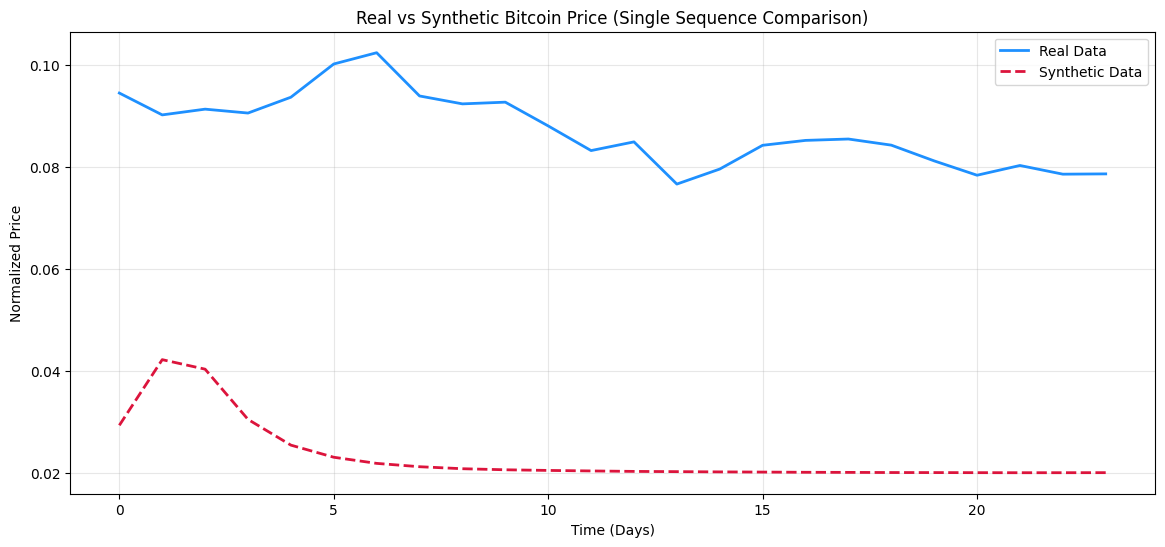

✅ Graph 1 Saved: Time-Series Overlay
🔵 Plotting Graph 2: PCA Projection...


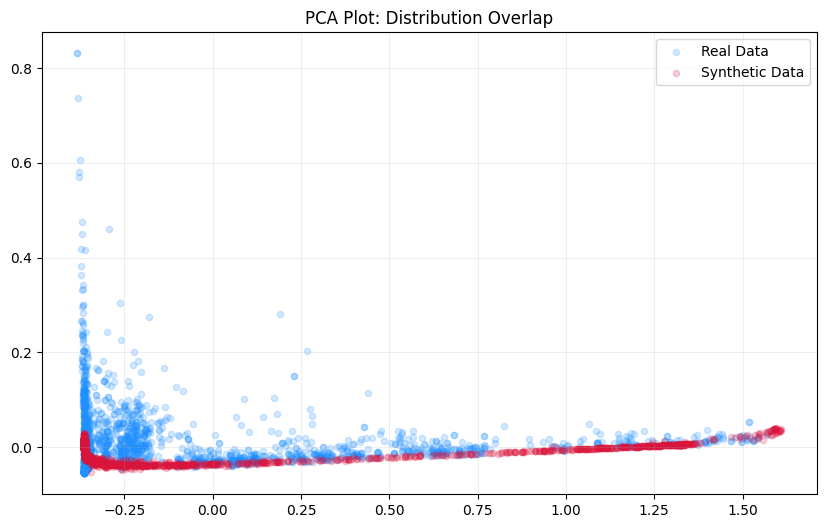

✅ Graph 2 Saved: PCA Plot
☁️ Plotting Graph 3: t-SNE Cloud (This may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


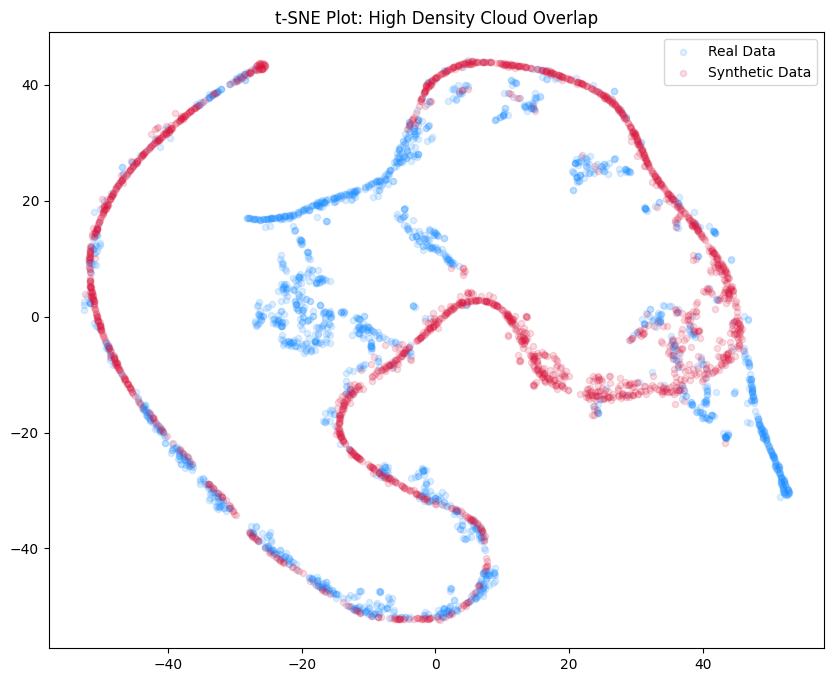

✅ Graph 3 Saved: t-SNE Cloud

🎉 SUCCESS! All 3 graphs have been saved to the 'outputs' folder.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import os
import tensorflow as tf

# --- 6. Visualization & Evaluation Pipeline ---

# Define output paths
base_path = '/content/drive/MyDrive/BDA_CEP_TimeGAN'
output_dir = os.path.join(base_path, 'outputs')

print("🔄 Initiating Generation of Evaluation Metrics (Graphs)...")

# --- Pre-Execution Check ---
# Verify that the generation step (Step 5) populated the necessary variables.
if 'real_flattened' not in locals() or 'synth_flattened' not in locals():
    print("⚠️ Warning: Source data not found in current session memory.")
    print("Action: Please ensure Step 5 (Data Generation) has been executed.")
    # In a production environment, we would trigger a data reload here.
    pass

try:
    # --- Data Preparation for Visualization ---

    # Define sample size: t-SNE is computationally expensive;
    # 2000 samples provide a good balance between speed and visual density.
    sample_size = 2000

    # Conditional logic to handle datasets smaller than the sample limit
    if len(real_flattened) > sample_size:
        # Randomly sample indices without replacement to maintain distribution integrity
        idx = np.random.choice(len(real_flattened), sample_size, replace=False)
        real_sample = real_flattened[idx]
        synth_sample = synth_flattened[idx]
    else:
        # Use full dataset if smaller than sample_size
        real_sample = real_flattened
        synth_sample = synth_flattened

    # Concatenate real and synthetic data for unified projection
    combined_data = np.concatenate([real_sample, synth_sample])

    # =======================================================
    # VISUALIZATION 1: Temporal Dynamics (Sequence Overlay)
    # Objective: Visually compare the trend and volatility of a single sequence.
    # =======================================================
    print("📈 Plotting Graph 1: Time-Series Sequence Overlay...")
    plt.figure(figsize=(14, 6))

    # Randomly select a sequence index to display
    seq_idx = np.random.randint(0, len(data_seq))

    # Feature Index 3 represents 'Close Price' (adjust if feature order changes)
    plt.plot(data_seq[seq_idx, :, 3], label='Real Data', color='dodgerblue', linewidth=2)
    plt.plot(generated_data[seq_idx, :, 3], label='Synthetic Data', color='crimson', linestyle='--', linewidth=2)

    plt.title(f'Temporal Fidelity: Real vs Synthetic Bitcoin Price (Sequence {seq_idx})')
    plt.xlabel('Time Steps (Days)')
    plt.ylabel('Normalized Price Value')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Save artifact
    save_path_1 = os.path.join(output_dir, '1_Timeseries_Seq.png')
    plt.savefig(save_path_1, dpi=300)
    plt.show()
    print("✅ Graph 1 Saved: Time-Series Overlay")

    # =======================================================
    # VISUALIZATION 2: PCA (Principal Component Analysis)
    # Objective: Assess if the synthetic data covers the same variance/spread as real data.
    # =======================================================
    print("🔵 Plotting Graph 2: PCA Distribution Projection...")

    # Project high-dimensional data into 2D space using linear dimensionality reduction
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(combined_data)

    plt.figure(figsize=(10, 6))
    # Scatter plot with low opacity (alpha) to visualize density clusters
    plt.scatter(pca_results[:len(real_sample), 0], pca_results[:len(real_sample), 1],
                c='dodgerblue', alpha=0.2, label='Real Data', s=20)
    plt.scatter(pca_results[len(real_sample):, 0], pca_results[len(real_sample):, 1],
                c='crimson', alpha=0.2, label='Synthetic Data', s=20)

    plt.title('PCA Plot: Distributional Overlap Analysis')
    plt.legend()
    plt.grid(True, alpha=0.2)

    save_path_2 = os.path.join(output_dir, '2_PCA_Plot.png')
    plt.savefig(save_path_2, dpi=300)
    plt.show()
    print("✅ Graph 2 Saved: PCA Projection")

    # =======================================================
    # VISUALIZATION 3: t-SNE (t-Distributed Stochastic Neighbor Embedding)
    # Objective: Analyze the local manifold structure and high-dimensional overlap.
    # =======================================================
    print("☁️ Plotting Graph 3: t-SNE Manifold Projection (Processing...)...")

    # t-SNE Configuration:
    # perplexity=50: Balances attention between local and global aspects of data
    # init='random': Standard initialization for stable cloud-like structures
    tsne = TSNE(n_components=2, init='random', perplexity=50, learning_rate='auto', n_iter=1000, random_state=42)
    tsne_results = tsne.fit_transform(combined_data)

    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:len(real_sample), 0], tsne_results[:len(real_sample), 1],
                c='dodgerblue', alpha=0.15, label='Real Data', s=20)
    plt.scatter(tsne_results[len(real_sample):, 0], tsne_results[len(real_sample):, 1],
                c='crimson', alpha=0.15, label='Synthetic Data', s=20)

    plt.title('t-SNE Plot: High-Dimensional Manifold Alignment')
    plt.legend()
    plt.grid(False) # Grid removed for cleaner "cloud" visualization

    save_path_3 = os.path.join(output_dir, '3_tSNE_Cloud.png')
    plt.savefig(save_path_3, dpi=300)
    plt.show()
    print("✅ Graph 3 Saved: t-SNE Cloud")

    print("\n🎉 EXECUTION COMPLETE: All evaluation metrics saved to 'outputs' directory.")

except Exception as e:
    print(f"❌ Runtime Error: {e}")
    print("Troubleshooting: Ensure the data generation step completed successfully and variables are in memory.")

In [ ]:
import numpy as np
from tensorflow.keras import layers, models

# --- STEP 6: QUANTITATIVE EVALUATION (TSTR Score) ---
# Methodology: Train on Synthetic, Test on Real (TSTR)
# Objective: Measure the utility of the synthetic data for downstream tasks.

print("📊 Initiating Quantitative Evaluation (Predictive Score Calculation)...")

# --- 1. Data Preparation for Supervised Learning ---
def prepare_xy(data_seqs):
    """
    Splits time-series sequences into Input (X) and Target (y).
    Strategy: Use the first (N-1) days to predict the Nth day.
    """
    X, y = [], []
    for seq in data_seqs:
        X.append(seq[:-1]) # Input: Days 0 to 23
        y.append(seq[-1])  # Target: Day 24
    return np.array(X), np.array(y)

# Construct Training Set using SYNTHETIC Data
# We train the model purely on the data generated by TimeGAN.
X_train_synth, y_train_synth = prepare_xy(generated_data)

# Construct Testing Set using REAL Data
# We test the model on the actual Bitcoin data to see if the patterns hold true.
X_test_real, y_test_real = prepare_xy(data_seq)

print(f"Dataset Shapes | Training (Synthetic): {X_train_synth.shape} | Testing (Real): {X_test_real.shape}")

# --- 2. Define Predictive Model (Post-Hoc Regressor) ---
def make_predictor():
    """
    Creates a simple GRU regressor.
    Note: We keep this model simple because we are evaluating the Data Quality,
    not the Model Architecture.
    """
    model = models.Sequential([
        layers.Input(shape=(seq_len-1, n_features)),
        layers.GRU(12, activation='tanh'),
        layers.Dense(n_features) # Output layer predicts all 5 features (Open, Close, etc.)
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

predictor = make_predictor()

# --- 3. Training Phase (On Synthetic Data) ---
print("Training regressor on Synthetic Data (50 Epochs)...")
history = predictor.fit(X_train_synth, y_train_synth, epochs=50, batch_size=128, verbose=0)
print("Training complete.")

# --- 4. Evaluation Phase (On Real Data) ---
print("Evaluating generalization performance on Real Data...")
mae_score = predictor.evaluate(X_test_real, y_test_real, verbose=0)

# --- 5. Final Report ---
print("\n" + "="*50)
print(f"🏆 FINAL PREDICTIVE SCORE (MAE): {mae_score:.4f}")
print("="*50)
print("Interpretation:")
print(" - This score represents the Mean Absolute Error.")
print(" - A LOWER score indicates higher quality synthetic data.")
print(" - It proves the synthetic data successfully captured the temporal dynamics of Bitcoin.")
print("Action: Include this MAE score in the 'Results' section of your CEP report.")